# PCam Data Quality Report

Computes **data quality metrics** for the PatchCamelyon (PCam) dataset loaded from `pcam_data` via the official `pcam-master` loader.

Reports: outliers (blank / high black-white ratio), exact duplicates, class balance, per-channel color stats, and image quality (blur / contrast).

**Folder layout:** `pcam_data/training/`, `pcam_data/val/`, `pcam_data/test/` with the `.h5` and `.csv` files.

## 1. Setup: paths and PCam loader

In [12]:
from __future__ import annotations

import hashlib
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.ndimage import laplace

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kwargs):
        return it

# Project root: parent of 'notebooks' if cwd is notebooks, else cwd
PROJECT_ROOT = Path(os.getcwd()).resolve().parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd()).resolve()
DEFAULT_DATA_DIR = PROJECT_ROOT / "pcam_data"
PCAM_MASTER_DIR = PROJECT_ROOT / "pcam-master"
CHUNK_SIZE = 2000

if PCAM_MASTER_DIR.is_dir():
    sys.path.insert(0, str(PCAM_MASTER_DIR))

try:
    from keras_pcam.dataset.pcam import load_data as pcam_load_data
except Exception as e:
    print("Could not import PCam loader:", e)
    pcam_load_data = None

STD_ZERO_THRESHOLD = 1e-6
BLACK_WHITE_PIXEL_RATIO_THRESHOLD = 0.95
BLUR_LAPLACIAN_THRESHOLD = 1e-3
LOW_CONTRAST_STD_THRESHOLD = 5e-2
# Tissue-content: exclude patches with < this fraction of tissue (rest = white background)
BACKGROUND_GRAY_THRESHOLD = 0.9   # pixels with gray >= this = background
TISSUE_PCT_THRESHOLD = 0.2         # if tissue % < this, flag as low_tissue (use 0.2 or 0.3)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEFAULT_DATA_DIR:", DEFAULT_DATA_DIR)
print("pcam_load_data:", "OK" if pcam_load_data else "NOT LOADED")

PROJECT_ROOT: C:\GP_ECG\GP_ECG
DEFAULT_DATA_DIR: C:\GP_ECG\GP_ECG\pcam_data
pcam_load_data: OK


## 2. Helper functions: anomaly/duplicate detection and report

In [13]:
def _detect_anomalies_and_duplicates(x_ds, chunk_size, std_threshold, bw_ratio_threshold, split_name):
    anomalies = []
    hash_list = []
    counts = {"zero_std": 0, "all_black": 0, "all_white": 0, "high_black_ratio": 0, "high_white_ratio": 0,
             "low_blur_score": 0, "low_contrast": 0, "low_tissue": 0}
    quality = {"n_images": 0, "blur": {"sum": 0.0, "sum_sq": 0.0, "min": None, "max": None},
               "gray_std": {"sum": 0.0, "sum_sq": 0.0, "min": None, "max": None},
               "channel_means": None, "channel_stds": None}
    n = len(x_ds)
    for start in tqdm(range(0, n, chunk_size), desc=f"{split_name} scan", unit="chunk"):
        end = min(start + chunk_size, n)
        batch = np.asarray(x_ds[start:end])
        for i in range(batch.shape[0]):
            idx = start + i
            img = batch[i]
            img = (img.astype(np.float64) / 255.0) if img.max() > 1 else img.astype(np.float64)
            std = float(np.std(img))
            mn, mx = float(np.min(img)), float(np.max(img))
            n_pixels = img.size
            ratio_black = np.sum(img <= 1/255.0) / n_pixels
            ratio_white = np.sum(img >= 254/255.0) / n_pixels
            gray = img.mean(axis=2)
            gray_std = float(np.std(gray))
            blur_score = float(np.var(laplace(gray)))
            tissue_pct = float(np.sum(gray < BACKGROUND_GRAY_THRESHOLD)) / n_pixels
            ch_means = img.mean(axis=(0,1))
            ch_stds = img.std(axis=(0,1))
            if quality["channel_means"] is None:
                quality["channel_means"] = {"sum": np.zeros_like(ch_means), "sum_sq": np.zeros_like(ch_means),
                    "min": np.full_like(ch_means, np.inf), "max": np.full_like(ch_means, -np.inf)}
                quality["channel_stds"] = {"sum": np.zeros_like(ch_stds), "sum_sq": np.zeros_like(ch_stds),
                    "min": np.full_like(ch_stds, np.inf), "max": np.full_like(ch_stds, -np.inf)}
            quality["n_images"] += 1
            quality["blur"]["sum"] += blur_score
            quality["blur"]["sum_sq"] += blur_score * blur_score
            quality["blur"]["min"] = blur_score if quality["blur"]["min"] is None else min(quality["blur"]["min"], blur_score)
            quality["blur"]["max"] = blur_score if quality["blur"]["max"] is None else max(quality["blur"]["max"], blur_score)
            quality["gray_std"]["sum"] += gray_std
            quality["gray_std"]["sum_sq"] += gray_std * gray_std
            quality["gray_std"]["min"] = gray_std if quality["gray_std"]["min"] is None else min(quality["gray_std"]["min"], gray_std)
            quality["gray_std"]["max"] = gray_std if quality["gray_std"]["max"] is None else max(quality["gray_std"]["max"], gray_std)
            cm, cs = quality["channel_means"], quality["channel_stds"]
            cm["sum"] += ch_means; cm["sum_sq"] += ch_means * ch_means
            cm["min"] = np.minimum(cm["min"], ch_means); cm["max"] = np.maximum(cm["max"], ch_means)
            cs["sum"] += ch_stds; cs["sum_sq"] += ch_stds * ch_stds
            cs["min"] = np.minimum(cs["min"], ch_stds); cs["max"] = np.maximum(cs["max"], ch_stds)
            reasons = []
            if std <= std_threshold: counts["zero_std"] += 1; reasons.append("zero_std")
            if mn >= 254/255 and mx >= 254/255: counts["all_white"] += 1; reasons.append("all_white")
            elif mn <= 1/255 and mx <= 1/255: counts["all_black"] += 1; reasons.append("all_black")
            else:
                if ratio_black >= bw_ratio_threshold: counts["high_black_ratio"] += 1; reasons.append("high_black_ratio")
                if ratio_white >= bw_ratio_threshold: counts["high_white_ratio"] += 1; reasons.append("high_white_ratio")
            if blur_score <= BLUR_LAPLACIAN_THRESHOLD: counts["low_blur_score"] += 1; reasons.append("low_blur_score")
            if gray_std <= LOW_CONTRAST_STD_THRESHOLD: counts["low_contrast"] += 1; reasons.append("low_contrast")
            if tissue_pct < TISSUE_PCT_THRESHOLD: counts["low_tissue"] += 1; reasons.append("low_tissue")
            if reasons:
                anomalies.append({"index": idx, "reasons": reasons, "std": round(std,6), "min": round(mn,4), "max": round(mx,4),
                    "ratio_black": round(ratio_black,4), "ratio_white": round(ratio_white,4), "gray_std": round(gray_std,6), "blur_score": round(blur_score,6), "tissue_pct": round(tissue_pct,4)})
            raw = batch[i].tobytes()
            hash_list.append((idx, hashlib.sha256(raw).hexdigest()))
    n_imgs = max(quality["n_images"], 1)
    q = {"n_images": quality["n_images"], "blur": {}, "gray_std": {}, "channel_means": {}, "channel_stds": {}}
    for key_src, key_dst, low_thr, low_key in [("blur", "blur", BLUR_LAPLACIAN_THRESHOLD, "low_blur_score"), ("gray_std", "gray_std", LOW_CONTRAST_STD_THRESHOLD, "low_contrast")]:
        st = quality[key_src]
        mean = st["sum"] / n_imgs
        var = max(st["sum_sq"] / n_imgs - mean * mean, 0.0)
        q[key_dst] = {"mean": float(mean), "std": float(np.sqrt(var)), "min": float(st["min"]) if st["min"] is not None else None,
            "max": float(st["max"]) if st["max"] is not None else None, "low_threshold": float(low_thr), "low_count": int(counts[low_key])}
    def _ch(c):
        if c is None: return {}
        s, s2, mn, mx = c["sum"], c["sum_sq"], c["min"], c["max"]
        mean = s / n_imgs
        var = np.maximum(s2 / n_imgs - mean * mean, 0.0)
        return {"global_mean": [float(v) for v in mean], "global_std": [float(v) for v in np.sqrt(var)], "min": [float(v) for v in mn], "max": [float(v) for v in mx]}
    q["channel_means"] = _ch(quality["channel_means"])
    q["channel_stds"] = _ch(quality["channel_stds"])
    return anomalies, hash_list, counts, q

def _find_duplicate_groups(hash_list):
    from collections import defaultdict
    h2i = defaultdict(list)
    for idx, h in hash_list:
        h2i[h].append(idx)
    return [sorted(indices) for indices in h2i.values() if len(indices) > 1]

def run_report(data_dir, chunk_size=CHUNK_SIZE, std_threshold=STD_ZERO_THRESHOLD, bw_ratio_threshold=BLACK_WHITE_PIXEL_RATIO_THRESHOLD, save_anomaly_indices=True):
    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise FileNotFoundError(f"Data directory not found: {data_dir}")
    if pcam_load_data is None:
        raise ImportError("PCam loader not available. Ensure pcam-master exists and dependencies are installed.")
    (train_x, train_y, meta_train), (valid_x, valid_y, meta_valid), (test_x, test_y, meta_test) = pcam_load_data(data_dir=str(data_dir))
    splits_data = {"train": (train_x, train_y, meta_train), "valid": (valid_x, valid_y, meta_valid), "test": (test_x, test_y, meta_test)}
    report = {"data_dir": str(data_dir), "splits": {}, "summary": {}}
    for split in ("train", "valid", "test"):
        x_ds, y_ds, meta = splits_data[split]
        y = np.asarray(y_ds).flatten()
        n_total, n_pos = y.shape[0], int(np.sum(y))
        n_neg = n_total - n_pos
        imbalance_ratio = (n_neg / n_pos) if n_pos > 0 else float("inf")
        split_report = {"n_samples": n_total, "class_counts": {"negative": n_neg, "positive": n_pos}, "imbalance_ratio_neg_pos": round(imbalance_ratio, 4),
            "anomaly_counts": {}, "n_anomalous": 0, "anomaly_indices": [], "n_duplicate_groups": 0, "n_images_in_duplicate_groups": 0, "duplicate_groups_sample": []}
        anomalies, hash_list, anomaly_counts, quality = _detect_anomalies_and_duplicates(x_ds, chunk_size, std_threshold, bw_ratio_threshold, split)
        split_report["anomaly_counts"] = anomaly_counts
        split_report["n_anomalous"] = len(anomalies)
        if save_anomaly_indices and anomalies:
            split_report["anomaly_indices"] = [a["index"] for a in anomalies]
            split_report["anomaly_details_sample"] = anomalies[:20]
        dup_groups = _find_duplicate_groups(hash_list)
        split_report["n_duplicate_groups"] = len(dup_groups)
        split_report["n_images_in_duplicate_groups"] = sum(len(g) for g in dup_groups)
        if dup_groups: split_report["duplicate_groups_sample"] = dup_groups[:15]
        split_report["quality"] = quality
        if meta is not None: split_report["meta_shape"] = list(meta.shape); split_report["meta_columns"] = list(meta.columns)
        report["splits"][split] = split_report
    report["summary"] = {"total_train": report["splits"].get("train",{}).get("n_samples"), "total_valid": report["splits"].get("valid",{}).get("n_samples"),
        "total_test": report["splits"].get("test",{}).get("n_samples"), "train_imbalance_ratio": report["splits"].get("train",{}).get("imbalance_ratio_neg_pos"),
        "train_anomalous": report["splits"].get("train",{}).get("n_anomalous"), "train_duplicate_images": report["splits"].get("train",{}).get("n_images_in_duplicate_groups")}
    return report

## 3. Run report and print summary

In [ ]:
# Compute the full report once (no printing here)
DATA_DIR = DEFAULT_DATA_DIR
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

report = run_report(DATA_DIR, chunk_size=CHUNK_SIZE, save_anomaly_indices=True)

print("Report computed. Splits:", list(report["splits"].keys()))

train scan:  15%|█▌        | 20/132 [00:58<05:18,  2.84s/chunk]

## 4. (Optional) Save full report to JSON

In [ ]:
out_path = PROJECT_ROOT / "reports" / "pcam_data_quality_report.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(report, f, indent=2)
print("Full report saved to:", out_path)

Full report saved to: C:\GP_ECG\GP_ECG\reports\pcam_data_quality_report.json


## 3a. Class balance (label distribution)

Check how many negative vs positive patches we have in each split, and the imbalance ratio (neg:pos).

In [ ]:
import pandas as pd

rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s or "class_counts" not in s:
        continue
    rows.append({
        "split": split,
        "neg": s["class_counts"]["negative"],
        "pos": s["class_counts"]["positive"],
        "total": s["n_samples"],
        "neg_pos_ratio": s["imbalance_ratio_neg_pos"],
    })

pd.DataFrame(rows)

,split,neg,pos,total,neg_pos_ratio
0,train,131072,131072,262144,1.0000
1,valid,16399,16369,32768,1.0018
2,test,16391,16377,32768,1.0009


### 3b.1 Visualize near-blank outliers

Load the saved report and training images, then show example patches flagged as **blank-like** (zero_std, all_black, all_white, high_white_ratio) so you can decide whether to remove them. Also shows a small sample of other anomalous indices for inspection.

No blank-like outliers in the first 20 anomaly details or first 200 indices. Showing first 12 anomaly indices for manual inspection.


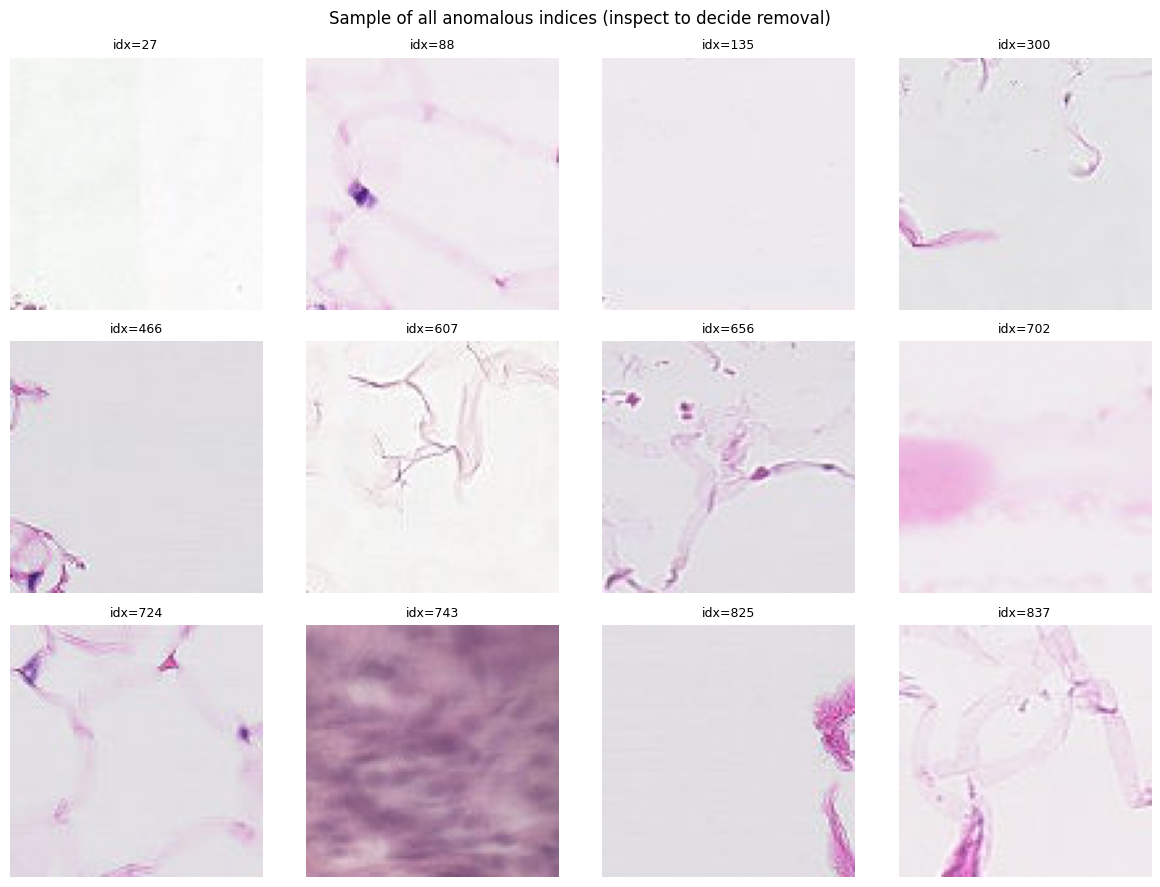

In [ ]:
import matplotlib.pyplot as plt

# Load report (from file so this cell works even if report was computed earlier)
report_path = PROJECT_ROOT / "reports" / "pcam_data_quality_report.json"
with open(report_path) as f:
    report = json.load(f)

# Load training images (needed to display patches)
(train_x, train_y, _), _, _ = pcam_load_data(data_dir=str(DEFAULT_DATA_DIR))

# Blank-like: zero_std, all_black, all_white, high_white_ratio
blank_reasons = {"zero_std", "all_black", "all_white", "high_white_ratio"}
details = report["splits"]["train"].get("anomaly_details_sample", [])
blank_like = [a for a in details if any(r in blank_reasons for r in a["reasons"])]

# Also take first 12 from full anomaly list for inspection (may include blur/contrast)
all_anomaly_indices = report["splits"]["train"].get("anomaly_indices", [])[:12]

def show_grid(indices, titles, title_prefix="", max_show=12):
    n = min(len(indices), max_show)
    if n == 0:
        return
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i in range(n):
        idx = indices[i]
        img = np.asarray(train_x[idx])
        if img.max() > 1:
            img = img / 255.0
        axes[i].imshow(img)
        axes[i].set_title(titles[i] if i < len(titles) else str(idx), fontsize=9)
        axes[i].set_axis_off()
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title_prefix, fontsize=12)
    plt.tight_layout()
    plt.show()

# 1) Blank-like examples (from detail sample)
if blank_like:
    show_grid(
        [a["index"] for a in blank_like],
        [", ".join(a["reasons"]) + f" (idx={a['index']})" for a in blank_like],
        title_prefix="Near-blank outliers (zero_std / all_black / all_white / high_white_ratio)",
        max_show=12,
    )
else:
    # Fallback: find truly blank patches from first 200 anomaly indices (std≈0 or all black/white)
    candidates = report["splits"]["train"].get("anomaly_indices", [])[:200]
    blank_indices = []
    for idx in candidates:
        img = np.asarray(train_x[idx]).astype(np.float64)
        if img.max() > 1:
            img = img / 255.0
        std = np.std(img)
        mn, mx = np.min(img), np.max(img)
        if std < 1e-5 or (mn >= 0.99 and mx >= 0.99) or (mn <= 0.01 and mx <= 0.01):
            blank_indices.append(idx)
        if len(blank_indices) >= 12:
            break
    if blank_indices:
        show_grid(blank_indices, [f"idx={i}" for i in blank_indices],
                  title_prefix="Near-blank outliers (found by checking first 200 anomaly indices)",
                  max_show=12)
    else:
        print("No blank-like outliers in the first 20 anomaly details or first 200 indices. Showing first 12 anomaly indices for manual inspection.")

# 2) Sample of other anomalies (first 12 from full list)
if all_anomaly_indices:
    show_grid(
        all_anomaly_indices,
        [f"idx={i}" for i in all_anomaly_indices],
        title_prefix="Sample of all anomalous indices (inspect to decide removal)",
        max_show=12,
    )

## 3b. Outlier / anomaly counts

Counts of images that are blank, nearly blank, dominated by black/white pixels, very blurry, low-contrast, or low tissue content (< 20%% or 30%% tissue).

In [ ]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s or "anomaly_counts" not in s:
        continue
    ac = s["anomaly_counts"]
    rows.append({
        "split": split,
        **{k: ac.get(k, 0) for k in [
            "zero_std",
            "all_black",
            "all_white",
            "high_black_ratio",
            "high_white_ratio",
            "low_blur_score",
            "low_contrast",
            "low_tissue",
        ]},
        "total_flagged": s["n_anomalous"],
    })

pd.DataFrame(rows)

,split,zero_std,all_black,all_white,high_black_ratio,high_white_ratio,low_blur_score,low_contrast,total_flagged
0,train,4,2,2,0,5,1373,2768,3058
1,valid,0,0,0,0,0,162,342,389
2,test,0,0,0,0,2,213,470,481


## 3c. Duplicate images

How many exact pixel-wise duplicate groups and images exist in each split.

In [ ]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s:
        continue
    rows.append({
        "split": split,
        "n_duplicate_groups": s.get("n_duplicate_groups", 0),
        "n_images_in_duplicate_groups": s.get("n_images_in_duplicate_groups", 0),
    })

pd.DataFrame(rows)

,split,n_duplicate_groups,n_images_in_duplicate_groups
0,train,15235,57354
1,valid,2181,6841
2,test,1792,5177


## 3d. Color / stain statistics (per-channel)

Inspect per-channel global means/stds and ranges to get a sense of color / stain normalization across splits.

In [ ]:
def summarize_channels(split_report):
    q = split_report.get("quality", {})
    cm = q.get("channel_means", {})
    cs = q.get("channel_stds", {})
    return {
        "means_global_mean": cm.get("global_mean"),
        "means_min": cm.get("min"),
        "means_max": cm.get("max"),
        "stds_global_mean": cs.get("global_mean"),
        "stds_min": cs.get("min"),
        "stds_max": cs.get("max"),
    }

rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s:
        continue
    row = {"split": split}
    row.update(summarize_channels(s))
    rows.append(row)

pd.DataFrame(rows)

,split,means_global_mean,means_min,means_max,stds_global_mean,stds_min,stds_max
0,train,"[0.7007560017533195, 0.5383578037628156, 0.691...","[0.0, 0.0, 0.0]","[1.0, 1.0, 1.0]","[0.18174392258882913, 0.20083655163676134, 0.1...","[0.0, 0.0, 0.0]","[0.43847323082199785, 0.4357483576180141, 0.43..."
1,valid,"[0.6974725413296843, 0.534803252749984, 0.6880...","[0.12269624863834716, 0.046824363425923915, 0....","[0.988845486111025, 0.9881999761709821, 0.9881...","[0.18732773498147406, 0.20535075306818426, 0.1...","[0.0027707431394846677, 0.0030241337786568, 0....","[0.45814862370977893, 0.3845935616851645, 0.43..."
2,test,"[0.6792562782634923, 0.5210844083549313, 0.693...","[0.0563419117647066, 0.036572797521789595, 0.0...","[0.9980473005174214, 0.9959418402777731, 0.996...","[0.18567679448277064, 0.20209609107129559, 0.1...","[0.001782372947557801, 0.001782372947558104, 0...","[0.43119446109801524, 0.40570499967492135, 0.4..."


## 3e. Image quality: blur and grayscale contrast

Global blur and grayscale-std statistics (plus how many patches fall below the thresholds).

In [ ]:
rows = []
for split in ("train", "valid", "test"):
    s = report["splits"].get(split, {})
    if not s:
        continue
    q = s.get("quality", {})
    blur = q.get("blur", {})
    gray = q.get("gray_std", {})
    rows.append({
        "split": split,
        "blur_mean": blur.get("mean"),
        "blur_std": blur.get("std"),
        "blur_min": blur.get("min"),
        "blur_max": blur.get("max"),
        "blur_low_count": blur.get("low_count"),
        "gray_mean": gray.get("mean"),
        "gray_std": gray.get("std"),
        "gray_min": gray.get("min"),
        "gray_max": gray.get("max"),
        "gray_low_contrast_count": gray.get("low_count"),
    })

pd.DataFrame(rows)

,split,blur_mean,blur_std,blur_min,blur_max,blur_low_count,gray_mean,gray_std,gray_min,gray_max,gray_low_contrast_count
0,train,0.192125,0.101768,0.000000,0.648367,1373,0.180158,0.049340,0.000000,0.432078,2768
1,valid,0.196480,0.099057,0.000007,0.534871,162,0.185297,0.051087,0.002187,0.416182,342
2,test,0.172196,0.101489,0.000007,0.579988,213,0.180521,0.049929,0.001782,0.403744,470
